In [1]:
# 기본 라이브러리
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# 전처리와 평가를 위한 sklearn 라이브러리
from sklearn.model_selection import train_test_split
from sklearn.metrics import *
from sklearn.preprocessing import MinMaxScaler


# 파이토치 라이브러리
import torch
from torch import nn 
from torch.utils.data import DataLoader, TensorDataset
from torch.optim import Adam



In [2]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device)

cuda


In [3]:
#하나의 함수는 한개의 기능만 하게 만들어야지 유지 보수가 가능해야 함 
#하지만 여기는 tensor 바꿔주는 기능, dataloader 기능 두개가 들어가야함
def make_DataSet(x_train, x_val, y_train, y_val, batch_size = 32) :
    # 데이터 텐서로 변환
    x_train_tensor = torch.tensor(x_train, dtype=torch.float32)  #tensor로 바꿔줘야하는 이유: 자동으로 미분해주는거
    y_train_tensor = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
    x_val_tensor = torch.tensor(x_val, dtype=torch.float32)
    y_val_tensor = torch.tensor(y_val, dtype=torch.float32).view(-1, 1)


    # TensorDataset 생성: 텐서 데이터 세트로 합치기
    train_dataset = TensorDataset(x_train_tensor, y_train_tensor)


    # DataLoader 생성
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle = True)
    return train_loader, x_val_tensor, y_val_tensor



In [4]:
#신경망 학습 함수:
#어디서 학습할지(device). 데이터(dataloader) -> 모델(nn) -> 손실함수(lossfunction) -> 업데이트 (옵티마이저)

def train(dataloader, model, loss_fn, optimizer, device):
    size = len(dataloader.dataset) # 전체 데이터 세트의 크기
    num_batches = len(dataloader) # 배치 크기
    tr_loss = 0  #전체 오차


    model.train() # 학습하기 전에 학습 모드로 설정
    for x, y in dataloader: # 배치 단위로 로딩     배치 사이즈 만큼씨 데이터를 꺼내줌 (학습 데이터, 학습데이터 레이블)
        x, y = x.to(device), y.to(device) # 디바이스 지정


        # Feed Forward(순전파)
        pred = model(x)  #예측값   ->  sigmoid(예측값)
        loss = loss_fn(pred, y) #오차를 구하는 함수, BCE
        tr_loss += loss #전체 오차에 누적

        #loss : 한 배치에 대한 순전파의 오차
        # Backpropagation(오차 역전파)
        loss.backward() # (미분함수) 역전파를 통해 각 파라미터에 대한 오차의 기울기 계산   -> 기울기 까지만 계산된거임 (학습 식)
        optimizer.step() # (w 찾아짐) 옵티마이저가 모델의 파라미터를 업데이트  step으로 빼줘야하는것까지(학습 식)    이부분이 반복됨(기울기가 0에 가까워질떄가지)
        optimizer.zero_grad() # 옵티마이저의 기울기값 초기화.


    tr_loss /= num_batches # 모든 배치의 오차 평균
    return tr_loss.item()   #tr.loss(tensor)를 .item으로 뱉어야 ndarray 로 처리할 수 있다


In [5]:
def evaluate(x_val_tensor, y_val_tensor, model, loss_fn, device):
    model.eval() # 모델을 평가 모드로 설정


    with torch.no_grad(): # 평가 과정에서 기울기를 계산하지 않도록 설정
        x, y = x_val_tensor.to(device), y_val_tensor.to(device)
        pred = model(x)  #예측값 추출
        eval_loss = loss_fn(pred, y).item() # 예측값 pred와 목푯값 y 사이의 오차 계산

    #이거때문에 밑에 val_loss,_     <- _ 라는 변수명을 잡아준건데 안쓰겠다는거임
    return eval_loss, pred



In [6]:
def dl_learning_curve(tr_loss_list, val_loss_list):
    epochs = list(range(1, len(tr_loss_list)+1)) # 에포크 수 계산
    plt.plot(epochs, tr_loss_list, label='train_err', marker = '.') # 학습 오차 그래프
    plt.plot(epochs, val_loss_list, label='val_err', marker = '.') # 검증 오차 그래프
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend()
    plt.grid()
    plt.show()


In [7]:
# 데이터 로딩
path = 'https://bit.ly/titanic_simple_csv'
data = pd.read_csv(path)
data.head()


#숫자데이터만 가져다가 신경망 학습 시작할거임


,PassengerId,Survived,Pclass,Name,Sex,Age,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,7.2500,Southampton
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,71.2833,Cherbourg
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,7.9250,Southampton
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,53.1000,Southampton
4,5,0,3,"Allen, Mr. William Henry",male,35.0,8.0500,Southampton


In [8]:
target = 'Survived'
features = ['Sex', 'Age', 'Fare']
x = data.loc[:, features]
y = data.loc[:, target]



In [9]:
x = pd.get_dummies(x, columns = ['Sex'], drop_first = True)  #원핫
x.head()


,Age,Fare,Sex_male
0,22.0,7.2500,True
1,38.0,71.2833,False
2,26.0,7.9250,False
3,35.0,53.1000,False
4,35.0,8.0500,True


In [10]:
# 데이터 분할
x_train, x_val, y_train, y_val = train_test_split(x, y, test_size=.3)


# 스케일링
scaler = MinMaxScaler()
x_train = scaler.fit_transform(x_train)
x_val = scaler.transform(x_val)


# make_DataSet 입력을 위해 y_train, y_val를 넘파이 배열로 변환
y_train = y_train.values   #.values -> ndarray 를 반환
y_val = y_val.values


In [11]:
# 데이터 로더 준비
train_loader, x_val_ts, y_val_ts = make_DataSet(x_train, x_val, y_train, y_val, 32)



In [12]:
#첫 번째 배치만 로딩해서 살펴보기
for x, y in train_loader:
    print(f'Shape of x [rows, columns]: {x.shape}')    #row이 32개, column이 3개
    print(f'Shape of y: {y.shape} {y.dtype}') #y.shape이 2차원으로 들어가야함
    break


Shape of x [rows, columns]: torch.Size([32, 3])
Shape of y: torch.Size([32, 1]) torch.float32


In [13]:
n_feature = x.shape[1]
# 모델 구조 설계
model = nn.Sequential( nn.Linear(n_feature, 1),  #1개의 예측값이 sigmoid로 들어감
                nn.Sigmoid()   #이진 분류   -> 0부터 1사이의 range 로 나오게 하겠다
                ).to(device)
loss_fn = nn.BCELoss() #이진분류이기떄문에 BCE이다
optimizer = Adam(model.parameters(), lr=0.01) #ADAM, lr(학습률) <- hyperparmeter 신경망에서도 학습률이 중요


In [14]:
epochs = 50  #전체 데이터를 50번 학습하겠다 <- epoch이 크면 클수록  과적합이 생긴다 
tr_loss_list, val_loss_list = [], []
for t in range(epochs):
    tr_loss = train(train_loader, model, loss_fn, optimizer, device)  #1 ephoch 당 tr_loss
    val_loss,_ = evaluate(x_val_ts, y_val_ts, model, loss_fn, device) #1 ephoch 당 var_loss
    # 리스트에 loss 추가
    tr_loss_list.append(tr_loss)
    val_loss_list.append(val_loss)
    print(f'Epoch {t+1}, train loss : {tr_loss:4f}, val loss : {val_loss:4f}')


Epoch 1, train loss : 0.677250, val loss : 0.660096
Epoch 2, train loss : 0.660536, val loss : 0.643791
Epoch 3, train loss : 0.642477, val loss : 0.630206
Epoch 4, train loss : 0.627266, val loss : 0.617972
Epoch 5, train loss : 0.614776, val loss : 0.606932
Epoch 6, train loss : 0.601482, val loss : 0.596919
Epoch 7, train loss : 0.589971, val loss : 0.588661
Epoch 8, train loss : 0.578367, val loss : 0.581510
Epoch 9, train loss : 0.569215, val loss : 0.574368
Epoch 10, train loss : 0.561067, val loss : 0.568554
Epoch 11, train loss : 0.553126, val loss : 0.563592
Epoch 12, train loss : 0.547887, val loss : 0.559464
Epoch 13, train loss : 0.538230, val loss : 0.555946
Epoch 14, train loss : 0.533455, val loss : 0.552359
Epoch 15, train loss : 0.529870, val loss : 0.549586
Epoch 16, train loss : 0.526461, val loss : 0.548069
Epoch 17, train loss : 0.521485, val loss : 0.545757
Epoch 18, train loss : 0.520384, val loss : 0.544743
Epoch 19, train loss : 0.516852, val loss : 0.543494
Ep

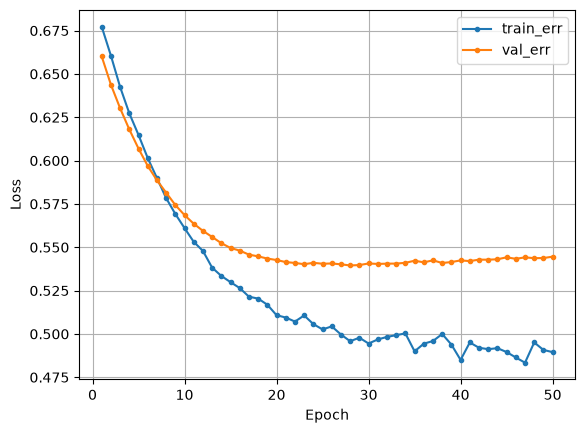

In [15]:
# 학습 곡선
dl_learning_curve(tr_loss_list, val_loss_list)


In [16]:
_, pred = evaluate(x_val_ts, y_val_ts, model, loss_fn, device)
print(pred.cpu().numpy()[:5])



[[0.72653294]
 [0.17860195]
 [0.20763355]
 [0.18263564]
 [0.74036944]]


In [17]:
pred = np.where(pred.cpu().numpy() > .5, 1, 0) #np.where 로 조건에 맞는 위치 찾기
print(pred[:5])


[[1]
 [0]
 [0]
 [0]
 [1]]


In [18]:
print(confusion_matrix(y_val_ts.numpy(), pred))  #원래답과 pred(예측값)

[[103  27]
 [ 26  58]]


In [19]:
print(classification_report(y_val_ts.numpy(), pred))



              precision    recall  f1-score   support

         0.0       0.80      0.79      0.80       130
         1.0       0.68      0.69      0.69        84

    accuracy                           0.75       214
   macro avg       0.74      0.74      0.74       214
weighted avg       0.75      0.75      0.75       214



In [20]:
#이진 분류 : 은닉층 추가
# 모델링에서 불필요한 열 제거
data = data.drop(['PassengerId', 'Name'], axis = 1)


# x, y분할
target = 'Survived'
x = data.drop(target, axis =1)
y = data.loc[:, target]


# 가변수화
x = pd.get_dummies(x, columns = ['Pclass', 'Sex', 'Embarked'], drop_first = True)


# train, val 분할
x_train, x_val, y_train, y_val = train_test_split(x, y, test_size=.3)


# 스케일러 선언
scaler = MinMaxScaler()
x_train = scaler.fit_transform(x_train)
x_val = scaler.transform(x_val)


# make_DataSet 입력을 위해 y_train, y_val을 넘파이 배열로 변환
y_train = y_train.values
y_val = y_val.values
train_loader, x_val_ts, y_val_ts = make_DataSet(x_train, x_val, y_train, y_val, 32)


In [21]:
n_feature = x.shape[1]
# 모델 구조 설계
model = nn.Sequential(nn.Linear(n_feature, 50),   #out_features = 5 이건 내 마음대로 줘도 됨 -> 커지면 학습을 더 많이 함
            nn.ReLU(),
            nn.Linear(50,5),
            nn.ReLU(),
            nn.Linear(5, 1),   #이진분류라서 output이 1이면됨 -> 그리고이걸 sigmoid ->  bce
            nn.Sigmoid()
            ).to(device)


loss_fn = nn.BCELoss()
optimizer = Adam(model.parameters(), lr=0.01)


In [22]:
model

Sequential(
  (0): Linear(in_features=7, out_features=50, bias=True)
  (1): ReLU()
  (2): Linear(in_features=50, out_features=5, bias=True)
  (3): ReLU()
  (4): Linear(in_features=5, out_features=1, bias=True)
  (5): Sigmoid()
)

In [23]:
tr_loss_list, val_loss_list = [], []
for t in range(epochs):
    tr_loss = train(train_loader, model, loss_fn, optimizer, device)
    val_loss,_ = evaluate(x_val_ts, y_val_ts, model, loss_fn, device)
    # 리스트에 loss 추가
    tr_loss_list.append(tr_loss)
    val_loss_list.append(val_loss)
    print(f'Epoch {t+1}, train loss : {tr_loss:4f}, val loss : {val_loss:4f}')


Epoch 1, train loss : 0.677261, val loss : 0.614563
Epoch 2, train loss : 0.519484, val loss : 0.559958
Epoch 3, train loss : 0.453685, val loss : 0.515616
Epoch 4, train loss : 0.454137, val loss : 0.521480
Epoch 5, train loss : 0.438810, val loss : 0.491301
Epoch 6, train loss : 0.428871, val loss : 0.489483
Epoch 7, train loss : 0.429896, val loss : 0.479988
Epoch 8, train loss : 0.435413, val loss : 0.514669
Epoch 9, train loss : 0.430444, val loss : 0.473728
Epoch 10, train loss : 0.422204, val loss : 0.480658
Epoch 11, train loss : 0.418726, val loss : 0.485658
Epoch 12, train loss : 0.422504, val loss : 0.466863
Epoch 13, train loss : 0.429312, val loss : 0.469361
Epoch 14, train loss : 0.425160, val loss : 0.471854
Epoch 15, train loss : 0.416467, val loss : 0.465760
Epoch 16, train loss : 0.410063, val loss : 0.461153
Epoch 17, train loss : 0.424797, val loss : 0.484342
Epoch 18, train loss : 0.415316, val loss : 0.467199
Epoch 19, train loss : 0.404881, val loss : 0.461976
Ep

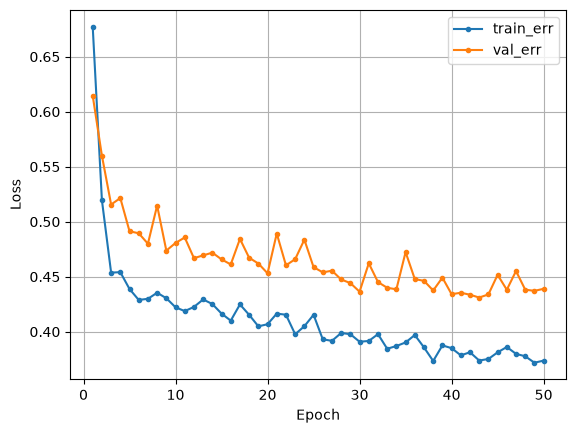

In [24]:
dl_learning_curve(tr_loss_list, val_loss_list)

In [25]:
# 직원 이직 예측
path = 'https://bit.ly/attri_csv'
data = pd.read_csv(path)
data.head()



,Attrition,Age,Department,DistanceFromHome,Education,EmployeeNumber,EnvironmentSatisfaction,Gender,JobSatisfaction,MaritalStatus,MonthlyIncome,NumCompaniesWorked,OverTime,PercentSalaryHike,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany
0,0,33,Research & Development,7,3,817,3,Male,3,Married,11691,0,No,11,0,14,3,4,13
1,0,35,Research & Development,18,2,1412,3,Male,4,Single,9362,2,No,11,0,10,2,3,2
2,0,42,Research & Development,6,3,1911,3,Male,1,Married,13348,9,No,13,1,18,3,4,13
3,0,46,Sales,2,3,1204,3,Female,1,Married,17048,8,No,23,0,28,2,3,26
4,1,22,Research & Development,4,1,593,3,Male,3,Single,3894,5,No,16,0,4,3,3,2


In [26]:
target = 'Attrition'
x = data.drop([target, 'EmployeeNumber'], axis = 1)
y = data.loc[:, target]
print(x.shape)


(1175, 17)


In [27]:
cat_cols = ['Department', 'Education', 'EnvironmentSatisfaction', 'Gender', 'JobSatisfaction', 'MaritalStatus', 'OverTime', 'WorkLifeBalance']
x = pd.get_dummies(x, columns = cat_cols, drop_first=True)
x.shape


(1175, 28)

In [28]:
# train, val 분할
x_train, x_val, y_train, y_val = train_test_split(x, y, test_size=.3)


# 스케일링
scaler = MinMaxScaler()
x_train = scaler.fit_transform(x_train)
x_val = scaler.transform(x_val)


# make_DataSet 입력을 위해 y_train, y_val을 넘파이 배열로 변환
y_train = y_train.values
y_val = y_val.values


In [29]:
train_loader, x_val_ts, y_val_ts = make_DataSet(x_train, x_val, y_train, y_val, 32)

In [31]:
from torchsummary import summary
n_feature = x.shape[1]
model = nn.Sequential(nn.Linear(n_feature, 16), nn.ReLU(),
            nn.Linear(16, 8), nn.ReLU(),
            nn.Linear(8, 1), nn.Sigmoid()
            ).to(device)
summary(model, input_size=(n_feature,))



----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Linear-1                   [-1, 16]             464
              ReLU-2                   [-1, 16]               0
            Linear-3                    [-1, 8]             136
              ReLU-4                    [-1, 8]               0
            Linear-5                    [-1, 1]               9
           Sigmoid-6                    [-1, 1]               0
Total params: 609
Trainable params: 609
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.00
Estimated Total Size (MB): 0.00
----------------------------------------------------------------


In [32]:
loss_fn = nn.BCELoss()
optimizer = Adam(model.parameters(), lr=0.001)


In [33]:
epochs = 50
tr_loss_list, val_loss_list = [], []
for t in range(epochs):
    tr_loss = train(train_loader, model, loss_fn, optimizer, device)
    val_loss,_ = evaluate(x_val_ts, y_val_ts, model, loss_fn, device)
    tr_loss_list.append(tr_loss)
    val_loss_list.append(val_loss)
    print(f'Epoch {t+1}, train loss : {tr_loss:4f}, val loss : {val_loss:4f}')


Epoch 1, train loss : 0.685658, val loss : 0.650415
Epoch 2, train loss : 0.585632, val loss : 0.565286
Epoch 3, train loss : 0.477803, val loss : 0.512786
Epoch 4, train loss : 0.421241, val loss : 0.512626
Epoch 5, train loss : 0.402893, val loss : 0.510975
Epoch 6, train loss : 0.401567, val loss : 0.505455
Epoch 7, train loss : 0.396970, val loss : 0.500716
Epoch 8, train loss : 0.390928, val loss : 0.491193
Epoch 9, train loss : 0.386829, val loss : 0.487143
Epoch 10, train loss : 0.382204, val loss : 0.481012
Epoch 11, train loss : 0.379016, val loss : 0.473777
Epoch 12, train loss : 0.376489, val loss : 0.471380
Epoch 13, train loss : 0.369767, val loss : 0.465105
Epoch 14, train loss : 0.363730, val loss : 0.458952
Epoch 15, train loss : 0.358349, val loss : 0.453705
Epoch 16, train loss : 0.353914, val loss : 0.447322
Epoch 17, train loss : 0.347802, val loss : 0.442179
Epoch 18, train loss : 0.344033, val loss : 0.434988
Epoch 19, train loss : 0.338910, val loss : 0.427529
Ep

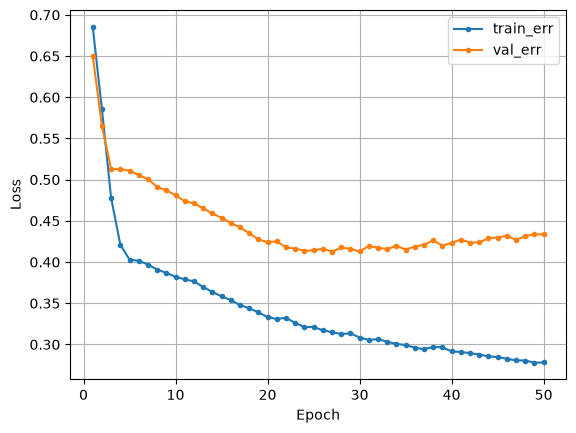

In [34]:
dl_learning_curve(tr_loss_list, val_loss_list)

